# RE LAT - Danggeun: D1–D60 Retention by OS

Author: @haewon.yum <br>
Last update: 2026-03-04

Compare post-re-engagement retention across iOS vs Android for Danggeun (Karrot) RE campaigns, using **MTID** as the user identifier. **Extended to D60 window.**

MTID provides coverage for iOS LAT/ATT-opted-out users who lack IDFA.

---

### Table of Contents
- [Step 0: Config](#step-0)
- [Step 1: Campaign Discovery](#step-1)
- [Step 2: Retention Data Pull](#step-2)
- [Step 3: Overall Retention by OS](#step-3)
- [Step 4: Retention Curve D0–D60](#step-4)
- [Step 5: Cohort Trend (Weekly)](#step-5)
- [Step 6: Event Breakdown](#step-6)
- [Step 7: Summary & Insights](#step-7)

In [31]:
#@title Step 0: Environment & Config {display-mode: "form"}

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set_style('whitegrid')

OS_COLORS = {'IOS': '#007AFF', 'ANDROID': '#3DDC84', 'ios': '#007AFF', 'android': '#3DDC84'}

client = bigquery.Client(project='moloco-ods')

def process_query(query):
    return client.query(query).result().to_dataframe()

print('Environment ready.')

Environment ready.


In [32]:
#@title Step 0: Configuration  <a id='step-0'></a>

# START_DATE AND END_DATE are applied to the impression time, not the cv timestamp.
START_DATE = '2026-01-01'
END_DATE   = '2026-02-01'

ADVERTISER_ID = 'Voql38wJkmDNzXbW'

# If you already know specific campaign IDs, list them here to skip discovery
KNOWN_CAMPAIGN_IDS = [
    'BFXaj4hUKW7Va5Bi',	# Android: KR_RE_moloco_maugrowth_show_fleamarket_feed_2512
    'JCbqtZCd2NehCzLL',	# iOS: KR_RE_moloco_maugrowth_AppOpen_IOS_251003
]

# Retention days to measure
RETENTION_DAYS = [1, 3, 7, 14, 30, 60]

# Optional: filter retention activity to a specific event name.
# Set to None to count ALL events (default behavior).
RETENTION_EVENT_NAME = 'show_fleamarket_feed'  # e.g. 'show_fleamarket_feed' or None

event_filter_sql = f"AND cv.cv.event_pb = '{RETENTION_EVENT_NAME}'" if RETENTION_EVENT_NAME else ""

print(f'Date range: {START_DATE} → {END_DATE}')
print(f'Advertiser ID: {ADVERTISER_ID}')
print(f'Retention checkpoints: D{"  D".join(str(d) for d in RETENTION_DAYS)}')
print(f'Retention event filter: {RETENTION_EVENT_NAME or "ALL events"}')

Date range: 2026-01-01 → 2026-02-01
Advertiser ID: Voql38wJkmDNzXbW
Retention checkpoints: D1  D3  D7  D14  D30
Retention event filter: show_fleamarket_feed


---
## Step 1: Campaign Discovery <a id='step-1'></a>

Identify Danggeun RE campaigns from `campaign_digest` × `product_digest`, grouped by OS.

In [33]:
#@title Step 1: Discover Danggeun RE campaigns

query_campaigns = f'''
SELECT
  cd.campaign_id,
  cd.campaign_title,
  cd.campaign_os AS os,
  cd.product_id,
  pd.tracking_bundle,
  cd.campaign_goal,
  cd.is_archived,
  JSON_VALUE(cd.original_json, '$.disabled') AS disabled
FROM `focal-elf-631.standard_digest.campaign_digest` cd
JOIN `focal-elf-631.standard_digest.product_digest` pd
  ON cd.product_id = pd.product_id
WHERE cd.campaign_type = 'APP_REENGAGEMENT'
  AND cd.advertiser_id = '{ADVERTISER_ID}'
  AND cd.is_archived = FALSE
  AND JSON_VALUE(cd.original_json, '$.disabled') = 'false'
ORDER BY cd.campaign_os, cd.campaign_title
'''

df_campaigns = process_query(query_campaigns)
print(f'Found {len(df_campaigns)} RE campaigns')
print(f'\nBy OS:')
print(df_campaigns.groupby('os').agg(
    n_campaigns=('campaign_id', 'nunique'),
    bundles=('tracking_bundle', lambda x: ', '.join(x.unique()))
))
print()
df_campaigns[['campaign_id', 'campaign_title', 'os', 'tracking_bundle', 'campaign_goal']]

Found 6 RE campaigns

By OS:
         n_campaigns           bundles
os                                    
ANDROID            5  com.towneers.www
IOS                1      id1018769995



,campaign_id,campaign_title,os,tracking_bundle,campaign_goal
0,naLfOc4evDfMS29y,KR_RE_LocalAds_AEO_CreateAd_AOS,ANDROID,com.towneers.www,OPTIMIZE_CPA_FOR_APP_RE
1,a9jBukYkyAH3pIMg,KR_RE_LocalAds_AEO_CreateBP_AOS,ANDROID,com.towneers.www,OPTIMIZE_CPA_FOR_APP_RE
2,A98pOZZEeLIcpNDZ,KR_RE_LocalAds_ROAS_BizCashSpent_BSP_AOS,ANDROID,com.towneers.www,OPTIMIZE_ROAS_FOR_APP_RE
3,BFXaj4hUKW7Va5Bi,KR_RE_moloco_maugrowth_show_fleamarket_feed_2512,ANDROID,com.towneers.www,OPTIMIZE_CPA_FOR_APP_RE
4,I0XBmycwRYKmehLG,KR_Re_LocalAds_ROAS_Payment_AOS,ANDROID,com.towneers.www,OPTIMIZE_ROAS_FOR_APP_RE
5,JCbqtZCd2NehCzLL,KR_RE_moloco_maugrowth_AppOpen_IOS_251003,IOS,id1018769995,OPTIMIZE_REATTRIBUTION_FOR_APP


In [34]:
#@title Step 1b: Finalize campaign IDs

if KNOWN_CAMPAIGN_IDS:
    campaign_ids = KNOWN_CAMPAIGN_IDS
    print(f'Using {len(campaign_ids)} manually specified campaign IDs')
else:
    campaign_ids = df_campaigns['campaign_id'].tolist()
    print(f'Using {len(campaign_ids)} discovered campaign IDs')

campaign_id_list = ', '.join(f"'{cid}'" for cid in campaign_ids)

campaign_os_map = dict(zip(df_campaigns['campaign_id'], df_campaigns['os']))
print(f'Campaign → OS mapping: {len(campaign_os_map)} entries')

Using 2 manually specified campaign IDs
Campaign → OS mapping: 6 entries


---
## Step 2: Retention Data Pull <a id='step-2'></a>

Pull all events from `cv` for the identified RE campaigns.

- **Time filter**: Based on `imp.happened_at` (impression time), not `cv.timestamp`. This ensures users whose impression was within `[START_DATE, END_DATE]` are captured even if their re-engagement event fires slightly later.
- **Activity window**: Extended to `END_DATE + 67 days` so D60 retention events are not truncated for late cohorts.
- **Cohort**: First `is_reengagement = TRUE` event per MTID where the impression falls within `[START_DATE, END_DATE]`.
- **Retention**: Any subsequent cv event on D+1, D+3, D+7, D+14, D+30, D+60

In [35]:
#@title Step 2: Pull retention data (main query)

query_retention = f'''
WITH
  campaigns AS (
    SELECT
      cd.campaign_id,
      cd.campaign_os AS os
    FROM `focal-elf-631.standard_digest.campaign_digest` cd
    WHERE cd.campaign_id IN ({campaign_id_list})
  ),

  re_events AS (
    SELECT
      cv.bid.mtid AS mtid,
      DATE(cv.timestamp) AS event_date,
      DATE(cv.imp.happened_at) AS imp_date,
      cv.cv.event_pb AS event_pb,
      cv.cv.pb.attribution.reengagement AS is_reengagement,
      cv.api.campaign.id AS campaign_id,
      c.os,
      cv.bid.maid AS maid
    FROM `focal-elf-631.prod_stream_view.cv` cv
    JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
    WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 67 DAY)
      AND DATE(cv.imp.happened_at) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND cv.bid.mtid IS NOT NULL
      AND cv.bid.mtid != ''
  ),

  cohort AS (
    SELECT
      mtid,
      os,
      maid,
      MIN(event_date) AS reengage_date
    FROM re_events
    WHERE is_reengagement = TRUE
      AND imp_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY 1, 2, 3
  ),

  daily_activity AS (
      SELECT DISTINCT cv.bid.mtid AS mtid, DATE(cv.timestamp) AS event_date
      FROM `focal-elf-631.prod_stream_view.cv` cv
      JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
      WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 67 DAY)
        AND cv.bid.mtid IS NOT NULL AND cv.bid.mtid != ''
        {event_filter_sql}
  )

SELECT
  c.os,
  c.reengage_date,
  c.mtid,
  c.maid,
  COUNT(DISTINCT da.event_date) AS active_days_post_d0,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 1 DAY) THEN 1 ELSE 0 END) AS ret_d1,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 3 DAY) THEN 1 ELSE 0 END) AS ret_d3,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 7 DAY) THEN 1 ELSE 0 END) AS ret_d7,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 14 DAY) THEN 1 ELSE 0 END) AS ret_d14,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 30 DAY) THEN 1 ELSE 0 END) AS ret_d30,
  MAX(CASE WHEN da.event_date = DATE_ADD(c.reengage_date, INTERVAL 60 DAY) THEN 1 ELSE 0 END) AS ret_d60
FROM cohort c
LEFT JOIN daily_activity da
  ON c.mtid = da.mtid
  AND da.event_date BETWEEN DATE_ADD(c.reengage_date, INTERVAL 1 DAY)
                        AND DATE_ADD(c.reengage_date, INTERVAL 60 DAY)
GROUP BY 1, 2, 3, 4
'''

print('Running retention query... (may take a few minutes)')
df_ret = process_query(query_retention)
print(f'Rows: {len(df_ret):,}  |  Unique MTIDs: {df_ret["mtid"].nunique():,}')
print(f'\nBy OS:')
print(df_ret.groupby('os')['mtid'].nunique().to_frame('unique_mtids'))
df_ret.head()

Running retention query... (may take a few minutes)
Rows: 528,506  |  Unique MTIDs: 528,506

By OS:
         unique_mtids
os                   
ANDROID        501717
IOS             26789


,os,reengage_date,mtid,maid,active_days_post_d0,ret_d1,ret_d3,ret_d7,ret_d14,ret_d30
0,ANDROID,2026-01-20,ChD-BR2N4K1OX6M1aGwEouZBEN_VvMsGGhQIARoQR0tDhh...,a:474b4386-129d-4939-a9e8-755bb9b4d3da,0,0,0,0,0,0
1,ANDROID,2026-01-05,ChCTnxov84NOQ7ipP5aUF4BmENyc7coGGhQIARoQXaJ8N-...,a:5da27c37-e547-4456-86f3-634f1b661927,0,0,0,0,0,0
2,ANDROID,2026-01-13,ChDBGRUNyEBBLalVU9GyiDibEN-dlssGGhQIARoQlqIxho...,a:96a23186-8097-4889-a34b-b228072f12c1,27,1,1,1,1,1
3,ANDROID,2026-01-26,ChAEW1Je47dG76JBmvio3QH7EIvxrssGGhQIARoQ_HoT2-...,a:fc7a13db-ea12-4236-a537-9579c8256df0,4,0,1,0,0,0
4,ANDROID,2026-01-09,ChCi071GVo1NSqXeBWrU9F44EOL9gssGGhQIARoQpKElC5...,a:a4a1250b-97b5-4cae-b6ab-580b3e13a62d,21,1,1,1,1,0


In [36]:
#@title Step 2b: Pull full daily retention curve (D0–D60)

query_daily_curve = f'''
WITH
  campaigns AS (
    SELECT cd.campaign_id, cd.campaign_os AS os
    FROM `focal-elf-631.standard_digest.campaign_digest` cd
    WHERE cd.campaign_id IN ({campaign_id_list})
  ),

  re_events AS (
    SELECT
      cv.bid.mtid AS mtid,
      DATE(cv.timestamp) AS event_date,
      DATE(cv.imp.happened_at) AS imp_date,
      cv.cv.pb.attribution.reengagement AS is_reengagement,
      c.os
    FROM `focal-elf-631.prod_stream_view.cv` cv
    JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
    WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 67 DAY)
      AND DATE(cv.imp.happened_at) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND cv.bid.mtid IS NOT NULL AND cv.bid.mtid != ''
  ),

  cohort AS (
    SELECT mtid, os, MIN(event_date) AS reengage_date
    FROM re_events
    WHERE is_reengagement = TRUE
      AND imp_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY 1, 2
  ),

  daily_activity AS (
      SELECT DISTINCT cv.bid.mtid AS mtid, DATE(cv.timestamp) AS event_date
      FROM `focal-elf-631.prod_stream_view.cv` cv
      JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
      WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 67 DAY)
        AND cv.bid.mtid IS NOT NULL AND cv.bid.mtid != ''
        {event_filter_sql}
  ),

  day_range AS (
    SELECT day_n FROM UNNEST(GENERATE_ARRAY(0, 60)) AS day_n
  )

SELECT
  c.os,
  d.day_n,
  COUNT(DISTINCT c.mtid) AS cohort_size,
  COUNT(DISTINCT CASE WHEN da.event_date IS NOT NULL THEN c.mtid END) AS retained
FROM cohort c
CROSS JOIN day_range d
LEFT JOIN daily_activity da
  ON c.mtid = da.mtid
  AND da.event_date = DATE_ADD(c.reengage_date, INTERVAL d.day_n DAY)
GROUP BY 1, 2
ORDER BY 1, 2
'''

print('Running daily curve query...')
df_curve = process_query(query_daily_curve)
df_curve['retention_rate'] = df_curve['retained'] / df_curve['cohort_size']
print(f'Rows: {len(df_curve)}')
df_curve

Running daily curve query...
Rows: 62


,os,day_n,cohort_size,retained,retention_rate
0,ANDROID,0,501717,260339,0.518896
1,ANDROID,1,501717,112355,0.223941
2,ANDROID,2,501717,35959,0.071672
3,ANDROID,3,501717,27256,0.054325
4,ANDROID,4,501717,25113,0.050054
5,ANDROID,5,501717,23856,0.047549
6,ANDROID,6,501717,23273,0.046387
7,ANDROID,7,501717,22973,0.045789
8,ANDROID,8,501717,22426,0.044699
9,ANDROID,9,501717,21919,0.043688


---
## Step 3: Overall Retention by OS <a id='step-3'></a>

=== Overall Retention by OS ===
     os  cohort_size  ret_d1  ret_d3  ret_d7  ret_d14  ret_d30  retention_d1  retention_d3  retention_d7  retention_d14  retention_d30
ANDROID       501717  112355   27256   22973    20152    17472        0.2239        0.0543        0.0458         0.0402         0.0348
    IOS        26789    2502     735     769      880     1015        0.0934        0.0274        0.0287         0.0328         0.0379


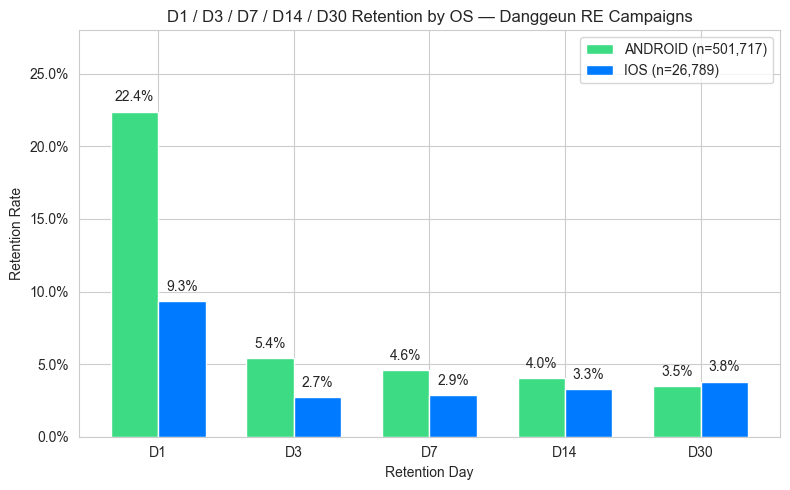

In [37]:
#@title Step 3: Summary table & bar chart

summary = df_ret.groupby('os').agg(
    cohort_size=('mtid', 'nunique'),
    ret_d1=('ret_d1', 'sum'),
    ret_d3=('ret_d3', 'sum'),
    ret_d7=('ret_d7', 'sum'),
    ret_d14=('ret_d14', 'sum'),
    ret_d30=('ret_d30', 'sum'),
    ret_d60=('ret_d60', 'sum'),
).reset_index()

for d in RETENTION_DAYS:
    summary[f'retention_d{d}'] = summary[f'ret_d{d}'] / summary['cohort_size']

print('=== Overall Retention by OS ===')
display_cols = ['os', 'cohort_size'] + [f'ret_d{d}' for d in RETENTION_DAYS] + [f'retention_d{d}' for d in RETENTION_DAYS]
print(summary[display_cols].to_string(index=False, float_format='{:.4f}'.format))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(RETENTION_DAYS))
width = 0.35
os_list = summary['os'].unique()

for i, os_val in enumerate(os_list):
    row = summary[summary['os'] == os_val].iloc[0]
    rates = [row[f'retention_d{d}'] for d in RETENTION_DAYS]
    bars = ax.bar(x + i * width - width / 2, rates, width,
                  label=f"{os_val} (n={int(row['cohort_size']):,})",
                  color=OS_COLORS.get(os_val, OS_COLORS.get(os_val.lower(), 'gray')))
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Retention Day')
ax.set_ylabel('Retention Rate')
ax.set_title('D1 / D3 / D7 / D14 / D30 / D60 Retention by OS — Danggeun RE Campaigns')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in RETENTION_DAYS])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.set_ylim(0, max(summary[[f'retention_d{d}' for d in RETENTION_DAYS]].max()) * 1.25)
plt.tight_layout()
plt.show()

---
## Step 4: Retention Curve D0–D60 <a id='step-4'></a>

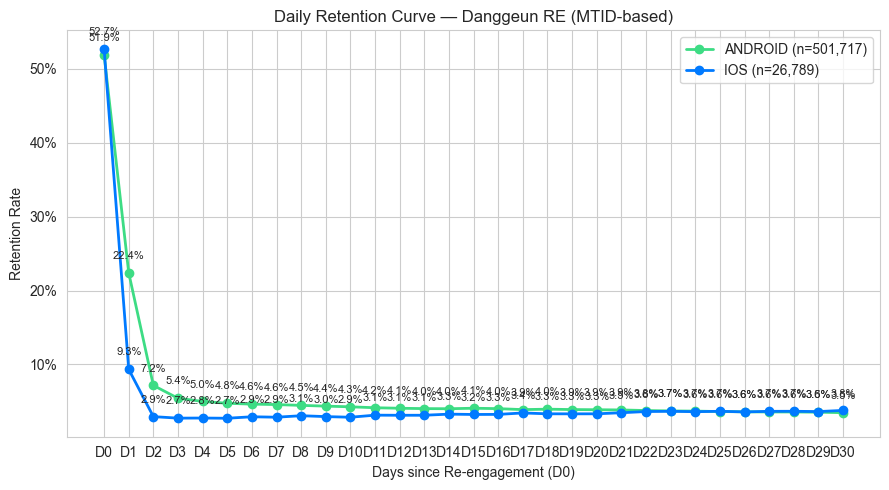

In [38]:
#@title Step 4: Daily retention curve

fig, ax = plt.subplots(figsize=(9, 5))

for os_val in df_curve['os'].unique():
    subset = df_curve[df_curve['os'] == os_val].sort_values('day_n')
    n = subset['cohort_size'].iloc[0]
    ax.plot(subset['day_n'], subset['retention_rate'],
            marker='o', linewidth=2,
            label=f'{os_val} (n={n:,})',
            color=OS_COLORS.get(os_val, OS_COLORS.get(os_val.lower(), 'gray')))
    for _, row in subset.iterrows():
        ax.annotate(f"{row['retention_rate']:.1%}",
                    (row['day_n'], row['retention_rate']),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8)

ax.set_xlabel('Days since Re-engagement (D0)')
ax.set_ylabel('Retention Rate')
ax.set_title('Daily Retention Curve — Danggeun RE (MTID-based)')
ax.set_xticks(range(31))
ax.set_xticklabels([f'D{i}' for i in range(31)])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 5: Cohort Trend (Weekly) <a id='step-5'></a>

Do retention rates improve or degrade over time? Group re-engagement dates into weekly cohorts.

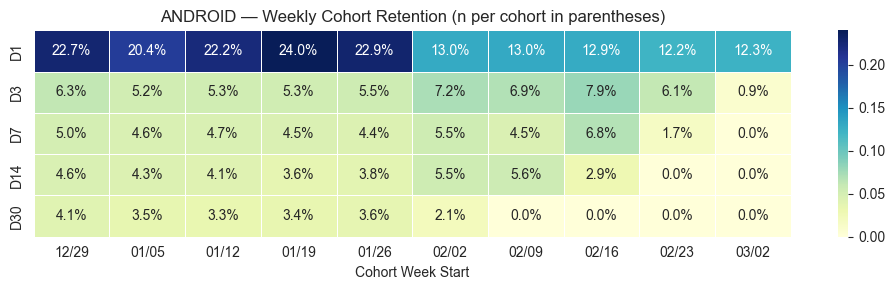


ANDROID weekly cohort sizes:
week_label  cohort_size
     12/29        46483
     01/05        99492
     01/12       111143
     01/19       123729
     01/26       115862
     02/02         1831
     02/09         1060
     02/16         1010
     02/23          781
     03/02          326



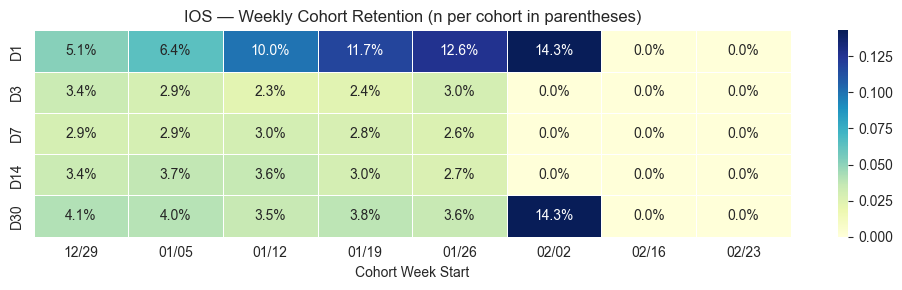


IOS weekly cohort sizes:
week_label  cohort_size
     12/29         3930
     01/05         6128
     01/12         5776
     01/19         5501
     01/26         5445
     02/02            7
     02/16            1
     02/23            1



In [39]:
#@title Step 5: Weekly cohort heatmap

df_ret['cohort_week'] = pd.to_datetime(df_ret['reengage_date']).dt.to_period('W').apply(lambda r: r.start_time)

cohort_data = df_ret.groupby(['os', 'cohort_week']).agg(
    cohort_size=('mtid', 'nunique'),
    ret_d1=('ret_d1', 'sum'),
    ret_d3=('ret_d3', 'sum'),
    ret_d7=('ret_d7', 'sum'),
    ret_d14=('ret_d14', 'sum'),
    ret_d30=('ret_d30', 'sum'),
    ret_d60=('ret_d60', 'sum'),
).reset_index()

for d in RETENTION_DAYS:
    cohort_data[f'rate_d{d}'] = (cohort_data[f'ret_d{d}'] / cohort_data['cohort_size']).astype(float)

for os_val in cohort_data['os'].unique():
    subset = cohort_data[cohort_data['os'] == os_val].copy()
    if len(subset) < 2:
        print(f'{os_val}: Not enough weekly cohorts for heatmap (n={len(subset)})')
        continue

    subset['week_label'] = subset['cohort_week'].dt.strftime('%m/%d')
    pivot = subset.set_index('week_label')[[f'rate_d{d}' for d in RETENTION_DAYS]].T
    pivot.index = [f'D{d}' for d in RETENTION_DAYS]

    fig, ax = plt.subplots(figsize=(max(10, len(subset) * 0.8), 3))
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax,
                linewidths=0.5, vmin=0)
    ax.set_title(f'{os_val} — Weekly Cohort Retention (n per cohort in parentheses)')
    ax.set_xlabel('Cohort Week Start')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    print(f'\n{os_val} weekly cohort sizes:')
    print(subset[['week_label', 'cohort_size']].to_string(index=False))
    print()

---
## Step 6: Event Breakdown <a id='step-6'></a>

Which postback events appear in the retention window? Helps understand the *quality* of re-engaged users.

In [40]:
#@title Step 6: Event breakdown query

query_events = f'''
WITH
  campaigns AS (
    SELECT cd.campaign_id, cd.campaign_os AS os
    FROM `focal-elf-631.standard_digest.campaign_digest` cd
    WHERE cd.campaign_id IN ({campaign_id_list})
  ),

  re_events AS (
    SELECT
      cv.bid.mtid AS mtid,
      DATE(cv.timestamp) AS event_date,
      DATE(cv.imp.happened_at) AS imp_date,
      cv.cv.event_pb AS event_pb,
      cv.cv.pb.attribution.reengagement AS is_reengagement,
      c.os
    FROM `focal-elf-631.prod_stream_view.cv` cv
    JOIN campaigns c ON cv.api.campaign.id = c.campaign_id
    WHERE DATE(cv.timestamp) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 67 DAY)
      AND DATE(cv.imp.happened_at) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND cv.bid.mtid IS NOT NULL AND cv.bid.mtid != ''
  ),

  cohort AS (
    SELECT mtid, os, MIN(event_date) AS reengage_date
    FROM re_events
    WHERE is_reengagement = TRUE
      AND imp_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY 1, 2
  )

SELECT
  c.os,
  re.event_pb,
  CASE
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) = 0 THEN 'D0'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 1 AND 1 THEN 'D1'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 2 AND 3 THEN 'D2-3'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 4 AND 7 THEN 'D4-7'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 8 AND 14 THEN 'D8-14'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 15 AND 30 THEN 'D15-30'
    WHEN DATE_DIFF(re.event_date, c.reengage_date, DAY) BETWEEN 31 AND 60 THEN 'D31-60'
  END AS day_bucket,
  COUNT(1) AS event_count,
  COUNT(DISTINCT c.mtid) AS unique_users
FROM cohort c
JOIN re_events re ON c.mtid = re.mtid
  AND re.event_date BETWEEN c.reengage_date AND DATE_ADD(c.reengage_date, INTERVAL 60 DAY)
GROUP BY 1, 2, 3
ORDER BY 1, 3, 4 DESC
'''

print('Running event breakdown query...')
df_events = process_query(query_events)
print(f'Rows: {len(df_events)}')

for os_val in df_events['os'].unique():
    print(f'\n=== {os_val} — Top Events by Day Bucket ===')
    subset = df_events[df_events['os'] == os_val]
    for bucket in ['D0', 'D1', 'D2-3', 'D4-7', 'D8-14', 'D15-30', 'D31-60']:
        b_data = subset[subset['day_bucket'] == bucket].nlargest(10, 'event_count')
        if len(b_data) > 0:
            print(f'\n  {bucket}:')
            print(b_data[['event_pb', 'event_count', 'unique_users']].to_string(index=False))

Running event breakdown query...
Rows: 951

=== ANDROID — Top Events by Day Bucket ===

  D0:
                   event_pb  event_count  unique_users
       show_fleamarket_feed      1113593        260325
               reengagement       501387        501343
               show_article       435072         51326
             show_jobs_main       163147         85354
completed_common_checkIn_v1        64561         32714
  show_jobs_job_post_detail        62305         21133
             event_check_in        50787         25876
 show_realty_article_detail        40240         12813
            show_story_feed        26687          7328
               click_search        25901         15524

  D1:
                    event_pb  event_count  unique_users
        show_fleamarket_feed       764735        112355
                show_article       438472         32402
 completed_common_checkIn_v1        61758         22051
              show_jobs_main        49380         22963
              

---
## Step 7: MAID Validation <a id='step-7'></a>

Check whether each MTID row has a valid MAID (IDFA / GAID) across iOS and Android.

In [41]:
#@title Step 7a: MAID validity check from existing df_ret

NULL_MAIDS = {None, '', '00000000-0000-0000-0000-000000000000'}

df_ret['maid_valid'] = ~df_ret['maid'].isin(NULL_MAIDS) & df_ret['maid'].notna()

print("=" * 70)
print("MAID Validation: does every MTID have a valid MAID?")
print("=" * 70)

for os_val in sorted(df_ret['os'].unique()):
    sub = df_ret[df_ret['os'] == os_val]
    total = len(sub)
    valid = sub['maid_valid'].sum()
    invalid = total - valid
    unique_mtids = sub['mtid'].nunique()
    unique_maids_valid = sub.loc[sub['maid_valid'], 'maid'].nunique()

    print(f"\n  {os_val}:")
    print(f"    Total MTID rows:      {total:>8,}")
    print(f"    Valid MAID:           {valid:>8,}  ({100*valid/total:.1f}%)")
    print(f"    Null/empty MAID:      {invalid:>8,}  ({100*invalid/total:.1f}%)")
    print(f"    Unique MTIDs:         {unique_mtids:>8,}")
    print(f"    Unique valid MAIDs:   {unique_maids_valid:>8,}")

    if unique_maids_valid > 0 and unique_mtids > 0:
        print(f"    MAID-to-MTID ratio:   {unique_maids_valid/unique_mtids:.3f}")

    # Show sample of null MAIDs
    null_sample = sub[~sub['maid_valid']]['maid'].value_counts().head(5)
    if not null_sample.empty:
        print(f"    Top null MAID values:")
        for val, cnt in null_sample.items():
            print(f"      '{val}': {cnt:,}")

MAID Validation: does every MTID have a valid MAID?

  ANDROID:
    Total MTID rows:       501,717
    Valid MAID:            501,717  (100.0%)
    Null/empty MAID:             0  (0.0%)
    Unique MTIDs:          501,717
    Unique valid MAIDs:    423,114
    MAID-to-MTID ratio:   0.843

  IOS:
    Total MTID rows:        26,789
    Valid MAID:             26,789  (100.0%)
    Null/empty MAID:             0  (0.0%)
    Unique MTIDs:           26,789
    Unique valid MAIDs:     26,752
    MAID-to-MTID ratio:   0.999


In [42]:
#@title Step 7b: How many MTIDs share a single MAID?

print("=" * 70)
print("MTIDs per MAID — by OS (valid MAIDs only)")
print("=" * 70)

valid_df = df_ret[df_ret['maid_valid']].copy()

if valid_df.empty:
    print("\n  No valid MAIDs found — cannot perform check.")
    print("  This is expected for iOS LAT campaigns (no IDFA).")
else:
    for os_val in sorted(valid_df['os'].unique()):
        sub = valid_df[valid_df['os'] == os_val]
        mtids_per_maid = sub.groupby('maid')['mtid'].nunique()
        total_maids = len(mtids_per_maid)

        print(f"\n  {os_val}  ({total_maids:,} unique valid MAIDs)")
        print(f"    MTIDs per MAID distribution:")
        for p in [50, 75, 90, 95, 99]:
            print(f"      p{p:2d}: {mtids_per_maid.quantile(p/100):>6.0f}")
        print(f"      max: {mtids_per_maid.max():>5}")

        print(f"\n    Breakdown:")
        print(f"      1 MTID  (1:1):   {(mtids_per_maid == 1).sum():>7,}  ({100*(mtids_per_maid == 1).mean():.1f}%)")
        print(f"      2 MTIDs:         {(mtids_per_maid == 2).sum():>7,}  ({100*(mtids_per_maid == 2).mean():.1f}%)")
        print(f"      3-5 MTIDs:       {((mtids_per_maid >= 3) & (mtids_per_maid <= 5)).sum():>7,}")
        print(f"      6-10 MTIDs:      {((mtids_per_maid >= 6) & (mtids_per_maid <= 10)).sum():>7,}")
        print(f"      11+ MTIDs:       {(mtids_per_maid >= 11).sum():>7,}")

        # Show the worst offenders
        top_shared = mtids_per_maid.sort_values(ascending=False).head(10)
        if top_shared.iloc[0] > 1:
            print(f"\n    Top 10 most-shared MAIDs:")
            print(f"      {'MAID':<40s}  MTIDs")
            print(f"      {'-'*40}  -----")
            for maid_val, cnt in top_shared.items():
                print(f"      {str(maid_val)[:40]:<40s}  {cnt:>5,}")

    # Cross-OS: same MAID appearing on both OS
    if len(valid_df['os'].unique()) > 1:
        maid_os = valid_df.groupby('maid')['os'].nunique()
        cross_os = (maid_os > 1).sum()
        print(f"\n  Cross-OS: {cross_os:,} MAIDs appear on both iOS and Android")

MTIDs per MAID — by OS (valid MAIDs only)

  ANDROID  (423,114 unique valid MAIDs)
    MTIDs per MAID distribution:
      p50:      1
      p75:      1
      p90:      2
      p95:      2
      p99:      3
      max:    31

    Breakdown:
      1 MTID  (1:1):   371,530  (87.8%)
      2 MTIDs:          45,270  (10.7%)
      3-5 MTIDs:         4,642
      6-10 MTIDs:          728
      11+ MTIDs:           944

    Top 10 most-shared MAIDs:
      MAID                                      MTIDs
      ----------------------------------------  -----
      a:7bcf8d2e-3f32-4c98-add7-ae818e394110       31
      a:6f87699f-d873-4782-a685-065ab117b3a0       31
      a:a8968397-7614-40d7-975a-f8175168c05c       31
      a:ec929f45-51b5-49a0-99bc-6e1a1720b142       31
      a:2814108b-7686-4af9-bdba-44aa8f5f811f       31
      a:4d3d6f9e-89e6-471a-8f72-57d964e069db       31
      a:061ec18b-07e0-45a1-a404-9760b92f4832       31
      a:85a6a918-a882-44ff-8535-2a00d024b133       31
      a:1dd4b15e-

---
## Step 8: Summary & Insights <a id='step-8'></a>

In [43]:
#@title Step 8: Summary

print('=' * 80)
print('DANGGEUN RE RETENTION ANALYSIS — SUMMARY')
print('=' * 80)
print(f'\nDate range: {START_DATE} → {END_DATE}')
print(f'Advertiser ID: {ADVERTISER_ID}')
print(f'Campaigns analyzed: {len(campaign_ids)}')
print(f'User identifier: MTID (covers LAT users on iOS)')
print(f'\n--- Overall Retention by OS ---')
for _, row in summary.iterrows():
    print(f"  {row['os']:10s}  n={int(row['cohort_size']):>8,}  "
          f"D1={row['retention_d1']:.2%}  D3={row['retention_d3']:.2%}  D7={row['retention_d7']:.2%}  D14={row['retention_d14']:.2%}  D30={row['retention_d30']:.2%}  D60={row['retention_d60']:.2%}")

# print(f'\n--- Key Observations ---')
# print('  [TODO: Fill in after running with real data]')
# print('  1. iOS vs Android retention gap: ...')
# print('  2. Retention trend over cohort weeks: ...')
# print('  3. Dominant post-RE events: ...')

# print(f'\n--- Caveats ---')
# print('  • iOS RE is LAT-only (no IDFA campaigns); Android serves as the baseline.')
# print('  • Retention measured from Moloco-attributed events only (cv table).')
# print('  • Organic returns not captured — true retention likely higher.')
# print('  • D0 = first RE-attributed event per MTID; multi-day RE users assigned to earliest cohort.')
# print('=' * 80)

DANGGEUN RE RETENTION ANALYSIS — SUMMARY

Date range: 2026-01-01 → 2026-02-01
Advertiser ID: Voql38wJkmDNzXbW
Campaigns analyzed: 2
User identifier: MTID (covers LAT users on iOS)

--- Overall Retention by OS ---
  ANDROID     n= 501,717  D1=22.39%  D3=5.43%  D7=4.58%  D14=4.02%  D30=3.48%
  IOS         n=  26,789  D1=9.34%  D3=2.74%  D7=2.87%  D14=3.28%  D30=3.79%


In [44]:
#@title (Optional) Export results to Excel

import os

output_dir = os.path.dirname(os.path.abspath('__file__'))
output_path = os.path.join(output_dir, 'RE_LAT_Danggeun_Retention_Results.xlsx')

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Retention by OS', index=False)
    df_curve.to_excel(writer, sheet_name='Daily Curve D0-30', index=False)
    df_ret.to_excel(writer, sheet_name='Raw Cohort Data', index=False)
    if 'df_events' in dir():
        df_events.to_excel(writer, sheet_name='Event Breakdown', index=False)

print(f'Exported to {output_path}')

Exported to /Users/haewon.yum/Documents/Queries/RE activation/RE LAT - Danggeun/RE_LAT_Danggeun_Retention_Results.xlsx


In [45]:
# end of notebook